# 03 — Marker genes and cluster annotation

In notebook 02 we produced Leiden clusters purely from expression
similarity — the algorithm has no idea what a "microglia" or "excitatory
neuron" is. This notebook is about the step that turns "cluster 7" into
"this is oligodendrocytes": **marker gene analysis**.

## Concepts before code

**Differential expression per cluster (`rank_genes_groups`).** For each
cluster, scanpy compares its expression profile against all other nuclei
pooled together (one-vs-rest), using a statistical test — we'll use the
**Wilcoxon rank-sum test**, a nonparametric test well-suited to the
non-normal, zero-inflated shape of expression data. The output for each
cluster is a ranked list of genes that are significantly higher in that
cluster than elsewhere, with an associated log fold-change.

**Marker genes.** A marker gene is a gene whose expression is
characteristic of a specific cell type, established from decades of prior
biology (not from this dataset). If a cluster's top differentially
expressed genes overlap heavily with a known marker panel for cell type X,
that's strong evidence the cluster *is* cell type X. We'll use the same
canonical cortical marker panel used in the companion R/Seurat project:

| Cell type | Markers |
|---|---|
| Excitatory neuron | SLC17A7, RORB, CUX2 |
| Inhibitory neuron | GAD1, GAD2, SST, PVALB, VIP |
| Astrocyte | AQP4, GFAP, SLC1A2 |
| Oligodendrocyte | PLP1, MOBP, MOG |
| OPC (oligodendrocyte precursor) | PDGFRA, CSPG4 |
| Microglia | C1QB, CSF1R, P2RY12 |
| Vascular (endothelial/mural) | CLDN5, FLT1, PECAM1 |

**Why validate against a reference?** It's tempting to trust your own
annotation once it "looks right," but the whole point of having SEA-AD's
independently-derived reference labels (`Class`/`Subclass`/`Supertype` in
`.obs`) is that we can *check our work* against ground truth we didn't use
as an input to clustering. Real analyses rarely have this luxury — treat it
as a chance to build calibration for how much to trust unsupervised
clustering + marker-based annotation in general.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
plt.rcParams["figure.dpi"] = 100

PROCESSED_DIR = "/Users/ugobruzadinnunes/Documents/GitHub/sea-ad-python-scanpy/data/processed"

adata = sc.read_h5ad(f"{PROCESSED_DIR}/adata_clustered.h5ad")
print(f"Loaded: {adata.n_obs:,} nuclei x {adata.n_vars:,} genes (HVG subset)")
print(f"adata.raw: {adata.raw.n_obs:,} nuclei x {adata.raw.n_vars:,} genes (full gene set, log-normalized)")
print(f"Leiden clusters: {sorted(adata.obs['leiden'].unique(), key=int)}")

Loaded: 152,212 nuclei x 2,000 genes (HVG subset)
adata.raw: 152,212 nuclei x 36,601 genes (full gene set, log-normalized)
Leiden clusters: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34']


Note we run marker-gene analysis on `adata.raw` (the full ~36,600-gene
log-normalized matrix stashed in notebook 02), not just the 2,000 HVGs —
some canonical markers may not have made the HVG cut, but they're still in
`.raw` and we want to be able to look them up regardless.

## Step 1 — worked example: unbiased top markers per cluster

First, let scanpy tell us the top differentially expressed genes per
cluster with no prior assumptions about cell type.

In [2]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=True)

# Top 5 genes per cluster, tidy table.
top_markers = sc.get.rank_genes_groups_df(adata, group=None)
top5_per_cluster = (
    top_markers.sort_values(["group", "pvals_adj", "logfoldchanges"], ascending=[True, True, False])
    .groupby("group")
    .head(5)
)
top5_per_cluster.pivot_table(
    index=top5_per_cluster.groupby("group").cumcount(), columns="group", values="names", aggfunc="first"
)

group,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,GPR17,ADARB2,ADARB2,SMYD1,AC113137.1,AC080079.2,AC016687.2,AC091096.1,CBLN2,FSHR,...,ST18,KIT,LINC02196,LAMA2,ADARB2,AC006305.1,AC046195.2,CHST8,FLT1,PTPRC
1,AC004852.2,NPR3,VIP,POSTN,AC109466.1,CNGB3,AP003066.1,LINC00343,LINC02714,AL450352.1,...,LINC01608,ADARB2,AC079380.1,CADM2,AL161629.1,LINC01416,NXPH1,KCNN2,ATP10A,PARP8
2,LINC02283,AC022523.1,TAC3,AC010401.1,AL445207.1,AC109466.1,AC099517.1,AL139379.1,LINC01484,LINC01474,...,LINC01792,EYA4,NPFFR2,CTNND2,CXCL14,ADARB2,ERBB4,GRM8,ELOVL7,CBLB
3,AL512308.1,CHRNA2,SLC22A3,TRPC7-AS1,MIR924HG,BARX2,AC060765.2,SH2D1B,LINC01500,AL356295.1,...,OPALIN,AC132803.1,ADGRL4,PPP2R2B,THSD7B,RELN,CHRM2,ESRRG,EPAS1,SKAP1
4,BEST3,AC013265.1,SHISA8,OLFML2B,AC008415.1,AC008415.1,AC097480.1,THEMIS,PDGFD,AC092598.1,...,FOLH1,FBXL7,AC099517.1,DOCK3,RELN,CXCL14,GPR149,SULF2,ABCB1,ARHGAP15


## Step 2 — score each cluster against the canonical marker panel

Rather than eyeballing gene names, we'll use `sc.tl.score_genes` — for each
canonical cell type, it computes a per-nucleus score (average expression of
that type's marker genes, minus a background control) — and then assign
each Leiden cluster the cell type whose score is highest *on average within
that cluster*. This is a simple but genuinely data-driven annotation
procedure (not just reading gene names off a dotplot).

In [3]:
marker_panel = {
    "Excitatory":     ["SLC17A7", "RORB", "CUX2"],
    "Inhibitory":     ["GAD1", "GAD2", "SST", "PVALB", "VIP"],
    "Astrocyte":      ["AQP4", "GFAP", "SLC1A2"],
    "Oligodendrocyte": ["PLP1", "MOBP", "MOG"],
    "OPC":            ["PDGFRA", "CSPG4"],
    "Microglia":      ["C1QB", "CSF1R", "P2RY12"],
    "Vascular":       ["CLDN5", "FLT1", "PECAM1"],
}

# Confirm every marker is actually present in the gene set before scoring.
for ct, genes in marker_panel.items():
    missing = [g for g in genes if g not in adata.raw.var_names]
    if missing:
        print(f"WARNING: {ct} missing genes: {missing}")

for cell_type, genes in marker_panel.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f"score_{cell_type}", use_raw=True)

score_cols = [f"score_{ct}" for ct in marker_panel]
cluster_scores = adata.obs.groupby("leiden")[score_cols].mean()
cluster_scores.columns = list(marker_panel.keys())
cluster_scores.round(3)

,Excitatory,Inhibitory,Astrocyte,Oligodendrocyte,OPC,Microglia,Vascular
leiden,,,,,,,
0,-0.419,0.058,0.376,-0.107,1.112,-0.029,-0.029
1,-0.567,0.291,-0.195,-0.133,-0.039,-0.048,-0.013
2,-0.498,0.288,-0.151,-0.123,-0.029,-0.040,0.058
3,-0.197,-0.098,-0.266,-0.133,-0.042,-0.040,0.092
4,0.154,-0.088,-0.150,-0.110,-0.041,-0.046,-0.010
5,0.327,-0.087,-0.130,-0.105,-0.041,-0.047,-0.008
6,0.230,-0.085,-0.130,-0.102,-0.037,-0.045,-0.006
7,-0.373,-0.090,-0.264,-0.104,-0.038,-0.044,-0.012
8,0.097,-0.083,-0.175,-0.104,-0.037,-0.045,-0.011


In [4]:
# Assign each cluster the cell type with the highest average score.
cluster_to_celltype = cluster_scores.idxmax(axis=1)
print("Cluster -> assigned cell type:")
print(cluster_to_celltype)

adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_to_celltype).astype("category")

Cluster -> assigned cell type:
leiden
0                 OPC
1          Inhibitory
2          Inhibitory
3            Vascular
4          Excitatory
5          Excitatory
6          Excitatory
7            Vascular
8          Excitatory
9          Excitatory
10         Excitatory
11         Excitatory
12         Excitatory
13         Inhibitory
14         Excitatory
15         Excitatory
16         Inhibitory
17           Vascular
18           Vascular
19         Inhibitory
20          Astrocyte
21          Astrocyte
22           Vascular
23          Microglia
24         Inhibitory
25    Oligodendrocyte
26         Inhibitory
27         Excitatory
28                OPC
29         Inhibitory
30         Inhibitory
31         Inhibitory
32           Vascular
33           Vascular
34           Vascular
dtype: object


## Visualizing the assignment: dotplot + UMAP

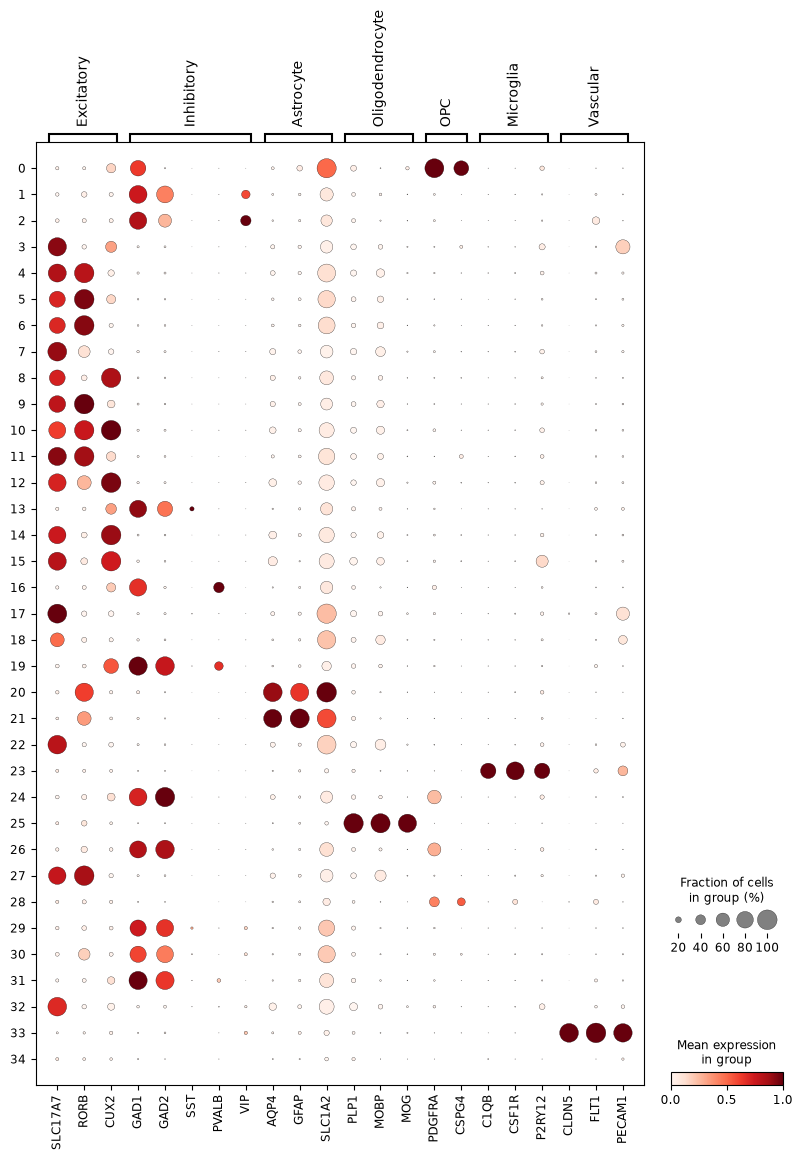

In [5]:
sc.pl.dotplot(
    adata, marker_panel, groupby="leiden", use_raw=True,
    standard_scale="var", dendrogram=False,
)

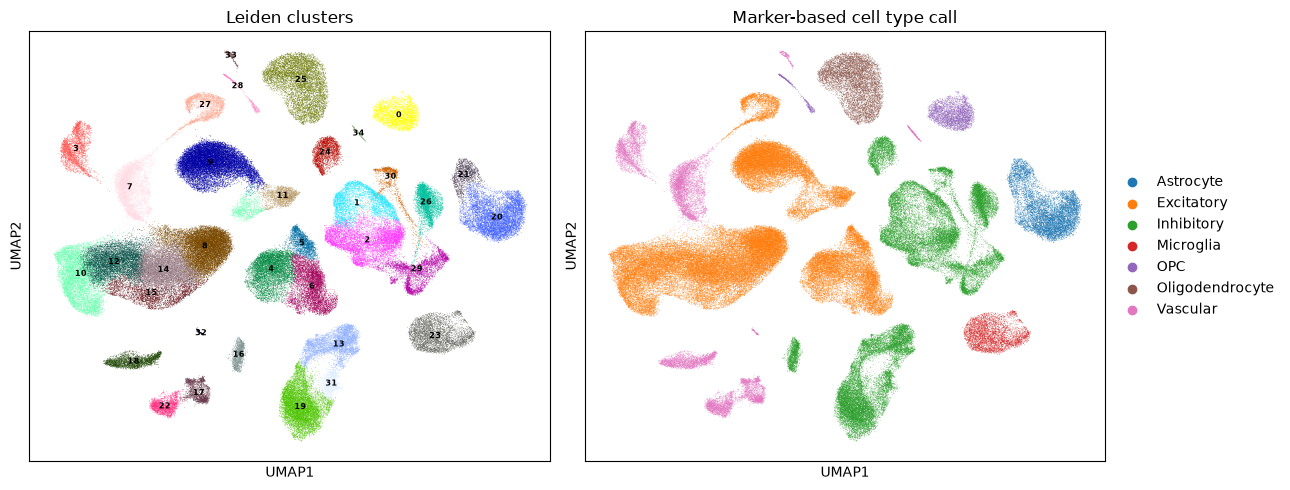

cell_type
Excitatory         74201
Inhibitory         39144
Vascular           14607
Astrocyte           8707
Oligodendrocyte     7241
Microglia           4314
OPC                 3998
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata, color="leiden", ax=axes[0], show=False, legend_loc="on data", legend_fontsize=6, title="Leiden clusters")
sc.pl.umap(adata, color="cell_type", ax=axes[1], show=False, title="Marker-based cell type call")
plt.tight_layout()
plt.show()

print(adata.obs["cell_type"].value_counts())

## Step 3 — validate against SEA-AD's reference labels

SEA-AD's `Subclass` column is much finer-grained than our 7-way panel (it
distinguishes cortical layers of excitatory neurons, individual inhibitory
subtypes, etc). We collapse it to the same 7 coarse categories so it's a
fair comparison, then cross-tabulate against our own calls.

In [7]:
subclass_to_coarse = {
    # Excitatory (layer-defined glutamatergic subtypes)
    "L2/3 IT": "Excitatory", "L4 IT": "Excitatory", "L5 IT": "Excitatory",
    "L6 IT": "Excitatory", "L6 IT Car3": "Excitatory", "L5/6 NP": "Excitatory",
    "L6 CT": "Excitatory", "L6b": "Excitatory", "L5 ET": "Excitatory",
    # Inhibitory (GABAergic subtypes)
    "Vip": "Inhibitory", "Pvalb": "Inhibitory", "Sst": "Inhibitory",
    "Sst Chodl": "Inhibitory", "Lamp5": "Inhibitory", "Lamp5 Lhx6": "Inhibitory",
    "Sncg": "Inhibitory", "Chandelier": "Inhibitory", "Pax6": "Inhibitory",
    # Non-neuronal
    "Astrocyte": "Astrocyte",
    "Oligodendrocyte": "Oligodendrocyte",
    "OPC": "OPC",
    "Immune": "Microglia",
    "Endothelial": "Vascular", "VLMC & Perivascular": "Vascular",
}

adata.obs["reference_coarse"] = adata.obs["Subclass"].map(subclass_to_coarse)
unmapped = adata.obs["reference_coarse"].isna().sum()
print(f"Nuclei with unmapped/unexpected Subclass values: {unmapped}")

confusion = pd.crosstab(adata.obs["cell_type"], adata.obs["reference_coarse"])
confusion

Nuclei with unmapped/unexpected Subclass values: 0


reference_coarse,Astrocyte,Excitatory,Inhibitory,Microglia,OPC,Oligodendrocyte,Vascular
cell_type,,,,,,,
Astrocyte,8706,0,0,1,0,0,0
Excitatory,0,74201,0,0,0,0,0
Inhibitory,0,0,39144,0,0,0,0
Microglia,0,0,0,4314,0,0,0
OPC,0,0,0,0,3512,0,486
Oligodendrocyte,0,0,0,0,2,7239,0
Vascular,0,14117,0,282,0,0,208


In [8]:
# Overall per-nucleus agreement rate between our marker-based call and the
# (collapsed) SEA-AD reference label.
matched = (adata.obs["cell_type"].astype(str) == adata.obs["reference_coarse"].astype(str))
agreement = matched.mean()
print(f"Overall agreement with SEA-AD reference (coarse): {agreement:.1%}")

per_type_agreement = (
    adata.obs.assign(match=matched)
    .groupby("reference_coarse")["match"]
    .mean()
    .sort_values(ascending=False)
)
print("\nAgreement rate by reference cell type:")
print(per_type_agreement.round(3))

Overall agreement with SEA-AD reference (coarse): 90.2%

Agreement rate by reference cell type:
reference_coarse
Astrocyte          1.000
Inhibitory         1.000
Oligodendrocyte    1.000
OPC                0.999
Microglia          0.938
Excitatory         0.840
Vascular           0.300
Name: match, dtype: float64


A simple 7-category, average-score cluster annotation typically gets the
big picture right (neurons vs. glia vs. vascular) but is exactly the kind
of shortcut that can misfire on: rare cell types (e.g. vascular cells are a
small minority and easy for a whole cluster to get "absorbed" into a
neighboring bigger class), doublet-contaminated clusters with genuinely mixed identity,
or marker genes that aren't as cell-type-specific as textbooks imply. Take
the agreement numbers above at face value, not as either "perfect, ignore
the reference" or "worthless, throw out clustering" — this is normal, and
is exactly why the reference-check step is worth doing rather than skipping.

## Recap

- `sc.tl.rank_genes_groups` (Wilcoxon test, one-vs-rest) finds genes that
  distinguish each cluster from the rest.
- We annotated clusters with a simple, reproducible scoring rule
  (`sc.tl.score_genes` per canonical marker set, assign the top-scoring
  type per cluster) rather than manual eyeballing.
- Cross-checking against SEA-AD's independent reference labels is a real
  accuracy check, not just a sanity vibe check — and it's honest about
  where our simple annotation over- or under-performs.

Next: **04_differential_expression_ad_pathology.ipynb** — using donor-level
AD pathology staging to ask whether gene expression differs by disease
severity within a specific, well-populated cell type.

## Homework

1. **Finer markers.** Add `NRGN` (pan-excitatory) and `GAD2`'s partner
   `SLC32A1` (pan-inhibitory, vesicular GABA transporter) to the marker
   panel dict, redo the scoring, and see whether any cluster's assignment
   flips.

2. **Write the code yourself:** find the single Leiden cluster with the
   *lowest* agreement rate with its mapped reference Subclass (per-cluster,
   not per-type — you'll need to group by `leiden` this time, not
   `reference_coarse`). Print the top 10 `rank_genes_groups` genes for that
   cluster and the `Subclass` value_counts within it. What's your best
   guess for what's going on?

3. **Interpretation.** Pick any one gene from the canonical marker panel
   you haven't previously worked with (e.g. `CSF1R` or `MOBP`) and look up
   its normal biological function. Does its role make sense as a marker for
   the cell type it's assigned to here?

4. **Modify the scoring approach.** `sc.tl.score_genes` uses a
   control-gene-subtracted average by default. Try an alternative: assign
   each cluster's cell type using only `rank_genes_groups` — i.e., check
   which canonical marker genes appear in each cluster's top 25
   differentially expressed genes, and assign the cell type with the most
   "hits." Does this change any assignments compared to the score-based
   approach?

In [9]:
# Q1 — your code here

In [10]:
# Q2 — your code here

Q3 — your answer here

In [11]:
# Q4 — your code here